# ANÁLISIS EXPLORATORIO DE DATOS CON PYTHON Y PANDAS

# 0. Pre-requisito

Se debe haber llevado a cabo la limpieza del set de datos, realizada en la clase anterior.

# 1. El problema del negocio

Una entidad bancaria contrata a una empresa de marketing encargada de contactar telefónicamente a posibles clientes para determinar si están interesados o no en adquirir un certificado de depósito a término con el banco.

¿Qué perfil tienen los clientes con mayor potencial de conversión?

# 2. El set de datos después de la limpieza

La información recolectada por la empresa de mercadeo se encuentra en un archivo CSV (`dataset_banco_clean.csv`) con 45189 filas y 17 columnas.

Cada registro contiene 16 características (las primeras 16 columnas) y una categoría ("yes" o "no" dependiendo de si la persona está o no interesada en adquirir el producto). Las columnas son:

1. "age":  edad (numérica)
2. "job": tipo de trabajo (categórica: "admin.", "unknown", "unemployed", "management", "housemaid", "entrepreneur", "student", "blue-collar","self-employed", "retired", "technician", "services")
3. "marital": estado civil (categórica: "married", "divorced", "single")
4. "education": nivel educativo (categórica: "unknown", "secondary", "primary", "tertiary")
5. "default": si dejó de pagar sus obligaciones (categórica: "yes", "no")
6. "balance": saldo promedio anual en euros (numérica)
7. "housing": ¿tiene o no crédito hipotecario? (categórica: "yes", "no")
8. "loan": ¿tiene créditos de consumo? (categórica: "yes", "no")
9. "contact": medio a través del cual fue contactado (categórica: "unknown", "telephone", "cellular")
10. "day": último día del mes en el que fue contactada (numérica)
11. "month": último mes en el que fue contactada (categórica: "jan", "feb", "mar", ..., "nov", "dec")
12. "duration": duración (en segundos) del último contacto (numérica)
13. "campaign": número total de veces que fue contactada durante la campaña (numérica)
14. "pdays": número de días transcurridos después de haber sido contactado antes de la campaña actual (numérica. -1 indica que no fue contactado previamente). Por eso es importante conocer los diccionarios. 
15. "previous": número de veces que ha sido contactada antes de esta campaña (numérica)
16. "poutcome": resultado de la campaña de marketing anterior (categórica: "unknown", "other", "failure", "success")
17. "y": categoría ¿el cliente se suscribió a un depósito a término? (categórica: "yes", "no")

#3. Lectura del dataset

In [1]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt #gráficos
import seaborn as sns #gráficos
import os

In [2]:
os.getcwd() #para ver en qué carpeta estoy trabajando

'/home/mgtdev/documentos_estudio/ESTADISTICA/IMD/Clases/Parte_1_preprocesamiento'

In [71]:
#Notese que seguimos usando la extensión .parquet 
#para que se mantenga la eficiencia 
ruta = "../../datos/datos_banco_limpio_optimizado.parquet"
data = pd.read_parquet(ruta)

In [72]:
print(data.shape)
data.head()

(45189, 17)


c:\Users\mtang\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\io\formats\format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143.0,yes,no,unknown,5,may,261.0,1,-1.0,0,unknown,no
1,44,technician,single,secondary,no,29.0,yes,no,unknown,5,may,151.0,1,-1.0,0,unknown,no
2,33,entrepreneur,married,secondary,no,2.0,yes,yes,unknown,5,may,76.0,1,-1.0,0,unknown,no
3,47,blue-collar,married,unknown,no,1506.0,yes,no,unknown,5,may,92.0,1,-1.0,0,unknown,no
4,33,unknown,single,unknown,no,1.0,no,no,unknown,5,may,198.0,1,-1.0,0,unknown,no


# 4. Análisis exploratorio

Un modelo es tan bueno como el conocimiento que se tenga del mismo, por tanto, el análisis es muy importante.

La idea es usar herramientas estadísticas y de visualización para:

- Crear un mapa mental del set de datos (entenderlo)
- Empezar a encontrar respuestas a la pregunta planteada inicialmente (¿qué perfil tienen los clientes con mayor potencial de inversión?)

Llevaremos a cabo estas fases:

1. Análisis de cada variable de manera individual
2. Análisis univariado: relación de cada variable predictora con la variable a predecir
3. Análisis bivariado: relación de pares de variables predictoras con la variable a predecir

## 4.1 Análisis de cada variable de manera individual

Nos permite entender las características generales de cada variable de nuestro set de datos. Notese que este es un análisis de manera estadística, para ver si es una variable numérica entonces su distribución de datos, presencia de atípicos, etc. En la limpieza también se hace esto pero la idea es revisar si hay cosas mal escritas y este tipo de colas por el estilo para luego hacer este análisis. 

In [73]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45189 entries, 0 to 45188
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45189 non-null  int8    
 1   job        45189 non-null  category
 2   marital    45189 non-null  category
 3   education  45189 non-null  category
 4   default    45189 non-null  category
 5   balance    45189 non-null  float32 
 6   housing    45189 non-null  category
 7   loan       45189 non-null  category
 8   contact    45189 non-null  category
 9   day        45189 non-null  int8    
 10  month      45189 non-null  category
 11  duration   45189 non-null  float16 
 12  campaign   45189 non-null  int8    
 13  pdays      45189 non-null  float16 
 14  previous   45189 non-null  int8    
 15  poutcome   45189 non-null  category
 16  y          45189 non-null  category
dtypes: category(10), float16(2), float32(1), int8(4)
memory usage: 972.9 KB


In [74]:
#notese que de esta manera nuestro dataset no pesa nisiquiera 1 MB
data.memory_usage().sum() / 1024**2 #en MB

np.float64(0.9500980377197266)

In [75]:
categoricas = data.select_dtypes(include=["object","category"])
categoricas.head() #tomamos el subconjutnod el dataframe
categoricas.columns #es una entidad del objeto datframe 

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\375061382.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\375061382.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\375061382.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\375061382.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(ax[i].get_xti

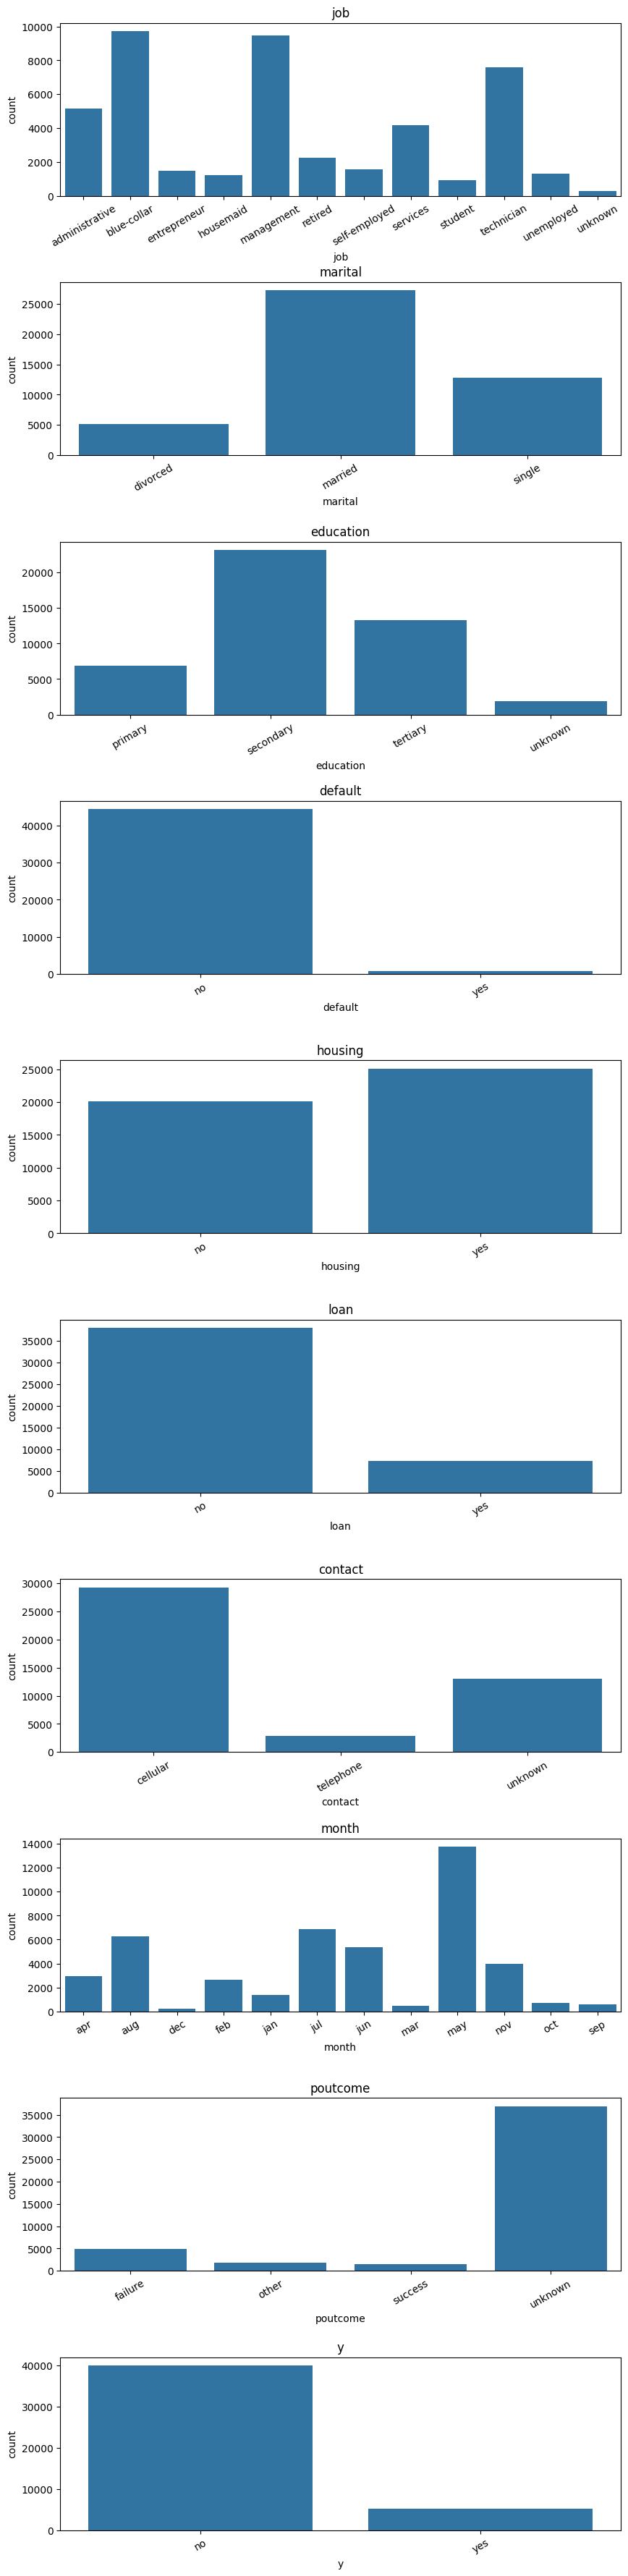

In [76]:
# Tomemos las variables categóricas y generemos gráficos de barras
#Notese que ahora no hay errores. Y pues con las variables categóricas no 
#se puede hacer mucho, solo conteos
col_cat = ['job', 'marital', 'education', 'default', 'housing',
       'loan', 'contact', 'month', 'poutcome', 'y']

# Gráficos de barras de conteo
#crear figura para gráficos de varias filas y 1 columna
#cada una con gráficas de tamaño 10 x 45 pulgadas
fig, ax = plt.subplots(nrows=len(col_cat), ncols=1, figsize=(10,45))
fig.subplots_adjust(hspace=0.5) #dejando un espacio de .5 pulgadas por gráfica

for i, col in enumerate(col_cat):
  #gráfico de barras o de conteo. 
  sns.countplot(x=col, data=data, ax=ax[i])
  #Titulos
  ax[i].set_title(col)
  #titulos de cad eje rotados
  ax[i].set_xticklabels(ax[i].get_xticklabels(),rotation=30)

**Observaciones:**

Niveles de cada variable de interés:
- 'job': 12
- 'marital': 3 (married, single, divorced)
- 'education': 4 (primary, secondary, tertiary, unknown)
- 'default': 2 (Yes, No). En este caso la gran mayoría de contactados tienen valores 'No'
- 'housing': 2 (Yes, No). En este caso el set está relativamente balanceado.
- 'loan': 2 (Yes, No). En este caso la gran mayoría contiene valores 'No'.
- 'poutcome': 4 (unknown, failure, other, success). La gran mayoría está en el nivel 'unknown'
- 'y': 2 (No, Yes). La gran mayoría está en el nivel 'No'. Si mas adelante se implemente algún modelo predictivo con Machine Learning se debe tener en cuenta este desbalance.

Es importante hacer anotaciones y hablar con el dueño de los datos para preguntarle que se podría eliminar. 

Es claro que esto aún no me dice nada acerca de mi variable respuesta u objetivo, sin embargo, es importante tener las características básicas de mis datos para más adelante tomar una decisión acertada. 

In [77]:
# Eliminemos las columnas "contact", "month", "day", "duration", "campaign",
# "pdays" y "previous" pues no aportan información sobre el cliente.
#en este caso, según el contexto, esto no nos da información necesaria y solo genera ruido. 

data.drop(columns=['contact','month', 'day', 'duration', 'campaign', 'pdays',
                   'previous'],inplace=True)
data.columns # es un atributo del data frame 

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'poutcome', 'y'],
      dtype='object')

Veamos inicialmente el comportamiento de las variables numéricas ('age' y 'balance')

In [78]:
#cuantitativas solo hay 2, es bueno ver su histograma  y us distribución
# Podemos extraer algunas variables estadísticas descriptivas básicas
data.describe() #estadísticos de variables cuantitativas

,age,balance
count,45189.000000,45189.000000
mean,40.936445,1374.012207
std,10.618502,3924.370117
min,18.000000,-8019.000000
25%,33.000000,72.000000
50%,39.000000,448.000000
75%,48.000000,1428.000000
max,95.000000,527532.000000


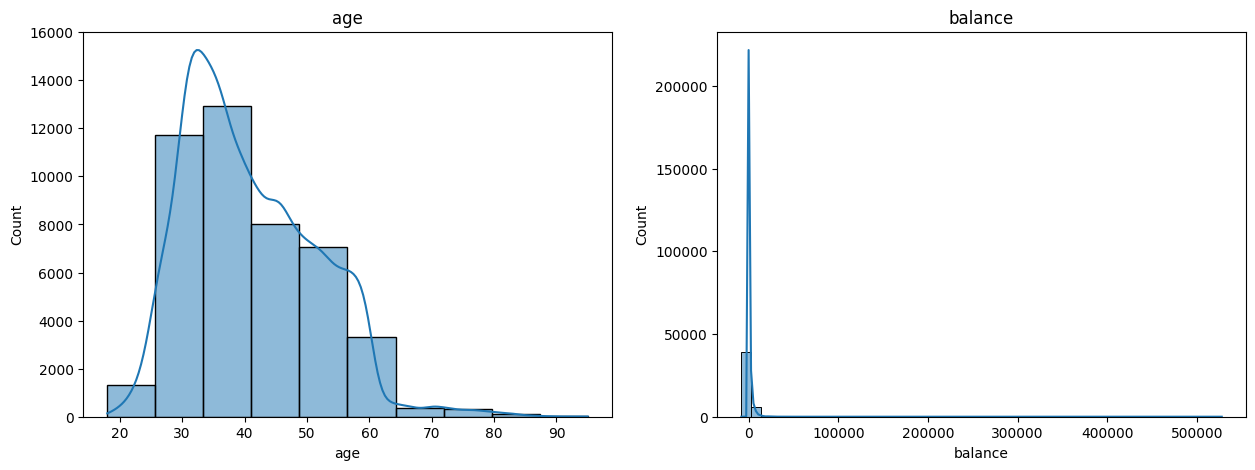

In [79]:
# Pero muchas veces es más útil graficar dichas variables

# Dibujar histogramas
col_num = ['age', 'balance']

#figura de 1 fila por 2 columnas
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
fig.subplots_adjust(hspace=0.5) #separadas por .5

for i, col in enumerate(col_num):
    if col == 'age':
        nbins = 10 #pocas barras
    else:
        nbins = 50 #muchas barras
    #para ambas un histograma
    sns.histplot(x=col, data=data, ax=ax[i], bins=nbins, kde = True)
    ax[i].set_title(col)

In [80]:
# Veamos en detalle lo que ocurre con balance
#estadísticos de esta variable. 
data['balance'].describe()

count     45189.000000
mean       1374.012207
std        3924.370117
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      527532.000000
Name: balance, dtype: float64

**Observaciones:**

- La mayor parte del grupo contactado tiene edades entre los 30 y los 50 años, con sesgo hacia los 30-40 años
- La mayor parte del grupo contactado (75%) tiene saldos o negativos o que no superan los 1500 euros aproximadamente.

## 4.2 Análisis univariado
Este análisis se basa en la comparación de las variables con la variable respuesta o objetivo, por tanto en este caso se compara solo de a 1 con esta objetivo. 

Teniendo claras algunas características generales de cada dato individual, la idea ahora es analizar si existe alguna relación entre las posibles variables predictoras ('age', 'balance', 'job', 'marital', 'education', etc.) y la variable a predecir ('y').

Esto se conoce como análisis univariado.

🟡 ADVERTENCIA

Este análisis nos mostrará sólo una faceta de las posibles relaciones entre una cada variable predictora y la variable a predecir, y no es suficiente para extraer conclusiones definitivas.

In [81]:
# Comencemos representando la variable a predecir de forma binaria:
# 'yes' = 1, 'no' = 0
diccionario = {'yes':1, 'no':0}
binario = data['y'].map(diccionario) #forma más eficiende DE PANDAS, lo único
#es que si hay un valor en Y que no este en mi diccionario, queda como NA

In [82]:
import numpy as np

In [83]:
# Ojo, como Y era de tipo category, y queremos pasarla a numérica,
# podemos usar astype(int) para convertirla a 0 y 1
data['y_bin'] = binario.astype(np.int8) #ahora es un entero de 8 bits, que es suficiente para 0 y 1
#como era de tipo categoría, basta con cambiarle el tipo de dato
#para llevarla a 0 y 1. 

In [84]:
data['y_bin'].value_counts() #conteo de 0 y 1
data['y_bin'].dtype #notese que es un entero

dtype('int8')

In [85]:
data.select_dtypes(include=["number"]).columns

Index(['age', 'balance', 'y_bin'], dtype='object')

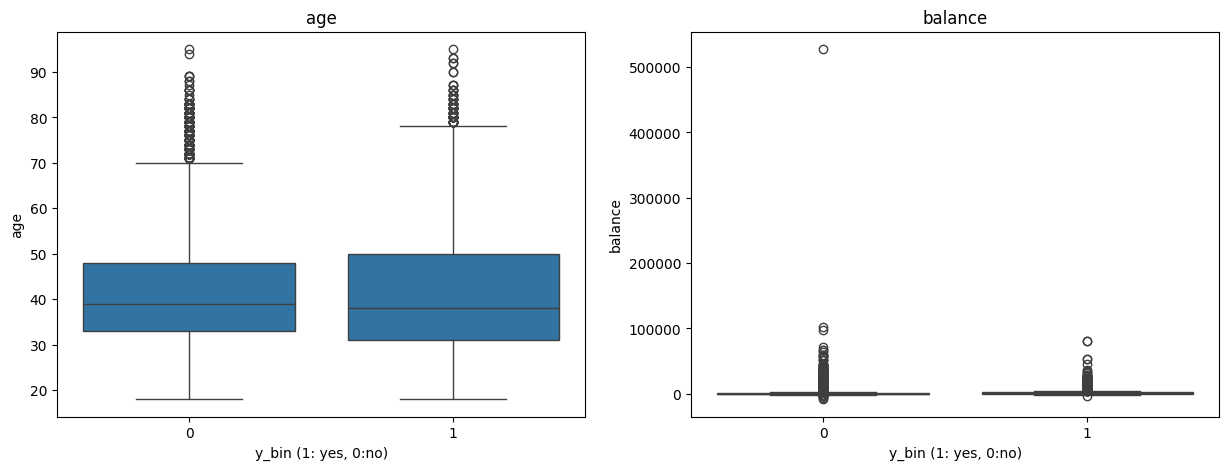

In [86]:
# Analizar la relación entre las variables numéricas y la variable a predecir ('y')
col_num = ['age','balance']
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
fig.subplots_adjust(hspace=.25)

for i, col in enumerate(col_num):
  #hacer boxplots, donde X es la variable respuesta categórica, y Y 
  # se llena con los datos de la columna 
  bplt = sns.boxplot(x="y_bin", y=col, data=data, ax=ax[i])
  ax[i].set_xlabel('y_bin (1: yes, 0:no)')
  ax[i].set_title(col)

**Observaciones:**
- Ni en 'age' ni en 'balance' se observan diferencias entre las personas que adquirieron o no el producto.
- Al parecer las variables numéricas no resultan en principio siendo variables predictivas.

Sin embargo estas variables numéricas se encuentran en un amplio rango.

Podemos calcular las tasas de conversión definiendo intervalos para estas variables numéricas y ver si podemos extraer información relevante de ese análisis:

In [95]:
# Función para graficar tasas de conversión

def graficar_tasas_conversion(var_predictora, var_predecir, type='line', order=None):
    x, y = var_predictora, var_predecir

    # Generar agrupaciones (groupby), calcular tasa de conversión (mean),
    # multiplicarla por 100 (mul(100))

    #El promedio de una variable binaria, se vuelve la proporción
    
    #.mul(100) convierte la proporción en porcentaje
    
    #reset_index() transfroma el resultado de un objeto series
    #de vuelta a un dataframe limpio con columnos independientes
    grupo = data.groupby(x)[y].mean().mul(100).rename('tasa_conv').reset_index()

    # Y generar gráfica que muestre la proporción de personas que dijeron
    #que si en el eje Y y las categorías de las variables predictoras en el eje X.
    if type=='line': # Útil para rangos continuos
        plt.figure(figsize=(10,6))
        sns.lineplot(x=var_predictora, y='tasa_conv', data=grupo)
        plt.ylabel('Proporción (%)')
        plt.xlabel('Variable Predictora')
        plt.grid()
    elif type=='bar': # Útil si los datos están divididos en rangos o son categóricos
        plt.figure(figsize=(14,6))
        sns.barplot(x=var_predictora, y='tasa_conv', data=grupo, order=order)
        plt.ylabel('Proporción (%)')
        plt.xlabel('Variable Predictora')
        plt.grid()
    elif type=='scatter': # Útil si los datos están divididos en rangos o son categóricos
        plt.figure(figsize=(10,6))
        sns.scatterplot(x=var_predictora, y='tasa_conv', data=grupo)
        plt.ylabel('Proporción (%)')
        plt.xlabel('Variable Predictora')
        plt.grid()

datos.groupby('A')['B'].operacion : 'A' es la variable categórica y 'B' es la numérica que se usara para la agrupación. Y la operación es la operación que harán los datos numéricos. 

In [ ]:
# Agrupar la variable edad por la variable numérica y_bin y sacarle el promedio
#viene a ser sacar la proporciónd de personas que dicen que si por grupo de edad. 
data.groupby('age')['y_bin'].mean()
data.groupby('age')['y_bin'].mean().mul(100) #llevar el decimal a procentaje
data.groupby('age')['y_bin'].mean().mul(100).rename('tasa_conv') #ponerle el nombre de tasa_conv  la columna
data.groupby('age')['y_bin'].mean().mul(100).rename('tasa_conv').reset_index() #para que quede un dataframe limpio
#pues el reset_index vuelve el resultado un data frame. 

#Acá es una serie
print(type(data.groupby('age')['y_bin'].mean().mul(100).rename('tasa_conv')))

#con reset_index() es un dataframe
print(type(data.groupby('age')['y_bin'].mean().mul(100).rename('tasa_conv').reset_index()))

#Nota: ojo, no necesariamente la primera variable tiene que ser numérica pues simplemente
#se mostrarán los valores de ella y se hará el conteo de la variable respuesta.
#es igual que un count de dos variables en R, se muestra el conteo de todas las posbiles combinaciones de las dos variables.

#y para ver el conteo de la variable sola es que se usa .value_counts() que sería
#el equivalente a un count de una sola variable en R.

<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>


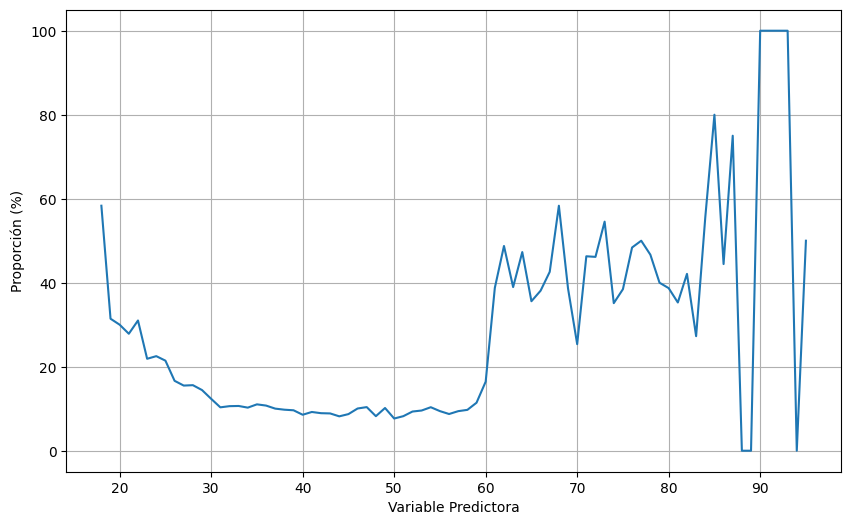

In [97]:
# Y graficar las tasas de conversión para la variable edad
#que representa el número de personas que dijeron que si, respecto a la edad. 
graficar_tasas_conversion('age','y_bin')

**Observaciones:**

- En este caso SÍ se observan diferencias en las tasas de conversión por edad
- Podríamos establecer tres rangos aproximados: 18-25 años, 26-59 años y 60 años en adelante

Es decir, el gráfico anterior dio a conocer el comportamiento de porporción de personas que dijeron que si, y es claro que podríamos separar por grupos de edad el comportamiento de las personas. 
Es decir, al ver la proporción de personas con la variable numérica edad, es posible identificar que entre algunas edades hay un comportamiento bastante similar y por ello puede ser más informativo simplemente hacer una discretización. 

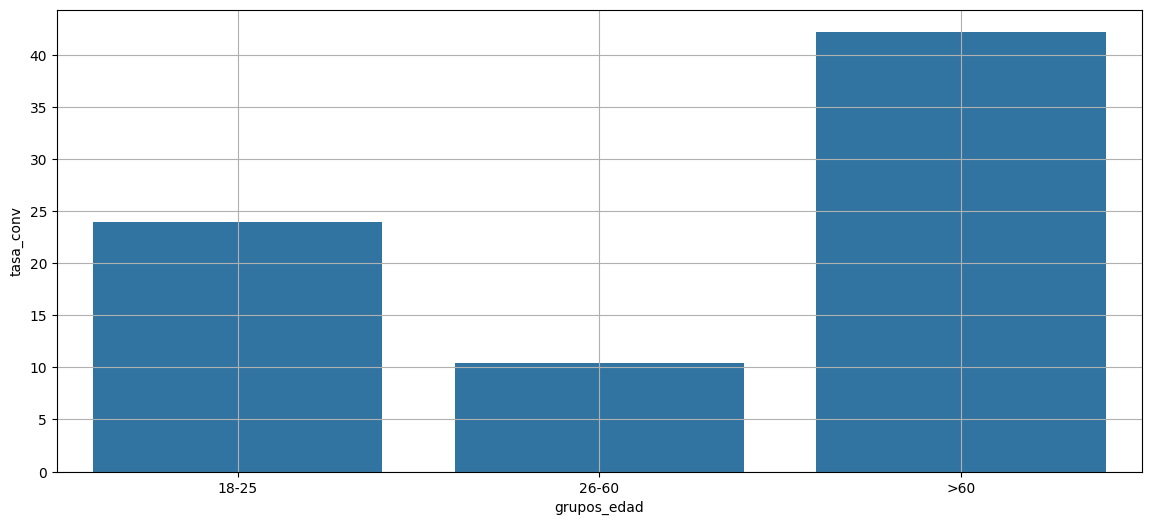

In [54]:
# Creemos subbrupos de edades y calculemos las tasas de conversión en cada caso

# Nueva columna en el dataset: "grupos_edad"
# Crear los grupos de edad. 
data.loc[:,'grupos_edad'] = "18-25" #llena todo con 18-25
data.loc[data['age']>60,'grupos_edad'] = ">60" #mayores de 60
data.loc[(data['age']>25)&(data['age']<=60), 'grupos_edad'] = "26-60" #entre 26 y 60

# Y grafiquemos la tasa de conversión para esta nueva columna
graficar_tasas_conversion('grupos_edad','y_bin',type='bar')

**Observaciones:**

- Tenemos 3 rangos de edad bastante diferenciados y para los cuales se alcanzan diferentes tasas de conversión: 18-25 años (24%), 26-60 años (11%), más de 60 años (43%)

Por tanto, en proporción los mayores de 60 suelen decir que si. 

In [98]:
# Y eliminemos la columna "age" (dejando sólo los grupos de edad)
data.drop(columns=['age'], inplace=True)

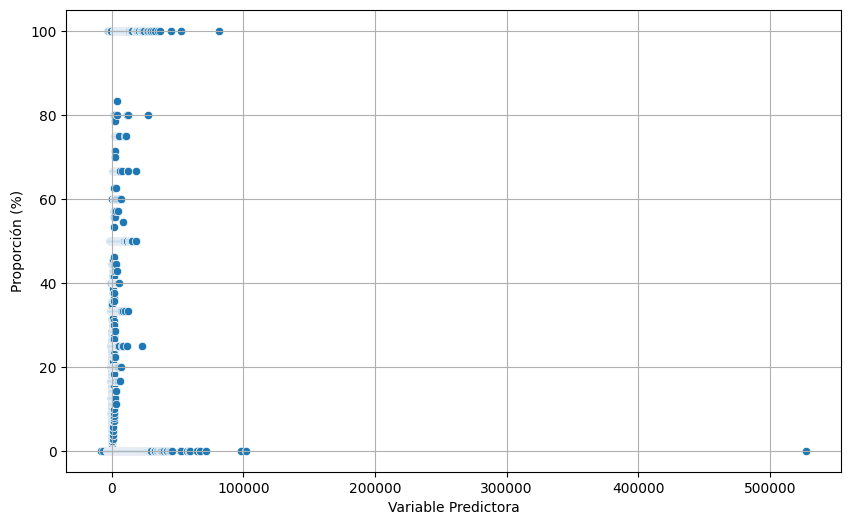

In [99]:
# Realicemos el mismo análisis pero para la variable 'balance'
graficar_tasas_conversion('balance','y_bin',type='scatter')

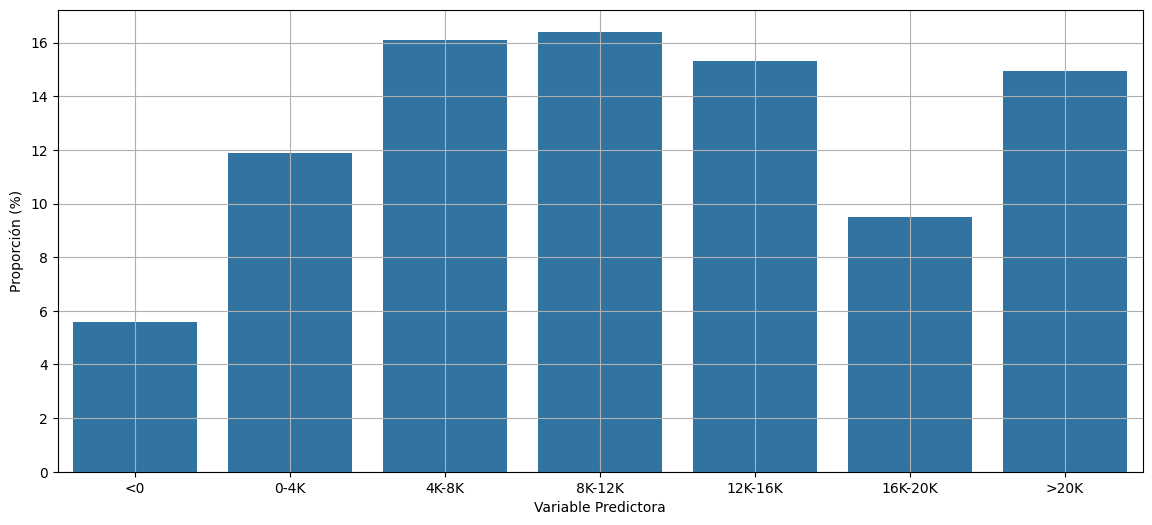

In [100]:
# No resulta fácil ver un patrón. Al igual que con la edad generemos
# diferentes rangos, esto ya denpe de la persona que rangos hacer, pero definitivamente
# no se logra diferenciar muy bien un patrón según esta variable. :
# <0
# 0-4000
# 4000-8000
# 8000-12000
# 12000-16000
# 16000-20000
# >20000

# Nueva columna en el dataset: "grupos_balance"
data.loc[:,'grupos_balance'] = "<0"
data.loc[(data['balance']>=0) & (data['balance']<4000),'grupos_balance'] = "0-4K"
data.loc[(data['balance']>=4000) & (data['balance']<8000),'grupos_balance'] = "4K-8K"
data.loc[(data['balance']>=8000) & (data['balance']<12000),'grupos_balance'] = "8K-12K"
data.loc[(data['balance']>=12000) & (data['balance']<16000),'grupos_balance'] = "12K-16K"
data.loc[(data['balance']>=16000) & (data['balance']<20000),'grupos_balance'] = "16K-20K"
data.loc[data['balance']>=20000,'grupos_balance'] = ">20K"

# Y grafiquemos la tasa de conversión para esta nueva columna
#graficar_tasas_conversion('grupos_balance','y_bin',type='bar')
orden = ['<0', '0-4K', '4K-8K', '8K-12K', '12K-16K', '16K-20K', '>20K']
graficar_tasas_conversion('grupos_balance','y_bin',type='bar', order=orden)

**Observaciones:**
No hay una forma clara para la variable, por tanto, la discretización es una opción  bastante viable y ver el comportamiento de las personas que dijeron que si según en este caso la variable balance. 
Notese que agrupar datos puede ser una gran idea para el manejo de variables numéricas, de esta manera se tiene control de datos atípicos. 

- Al parecer hay un patrón. Si organizamos las barras de forma ascendente observamos:
    - <0: 6%
    - 0-4K: 12%
    - 4K-8K: 16%
    - 8K-12K: 16%
    - 12K-16K: 15%
    - 16K-20K: 9%
    - Mayor a 20K: 15%

- Exceptuando el rango 16K-20K, en general un mayor nivel de liquidez genera una mayor tasa de conversión.
- Podríamos definir 4 rangos de interés para simplificar el análisis:
  - 0-4K
  - 4K-16K
  - 16K-20K
  - Mayor a 20K

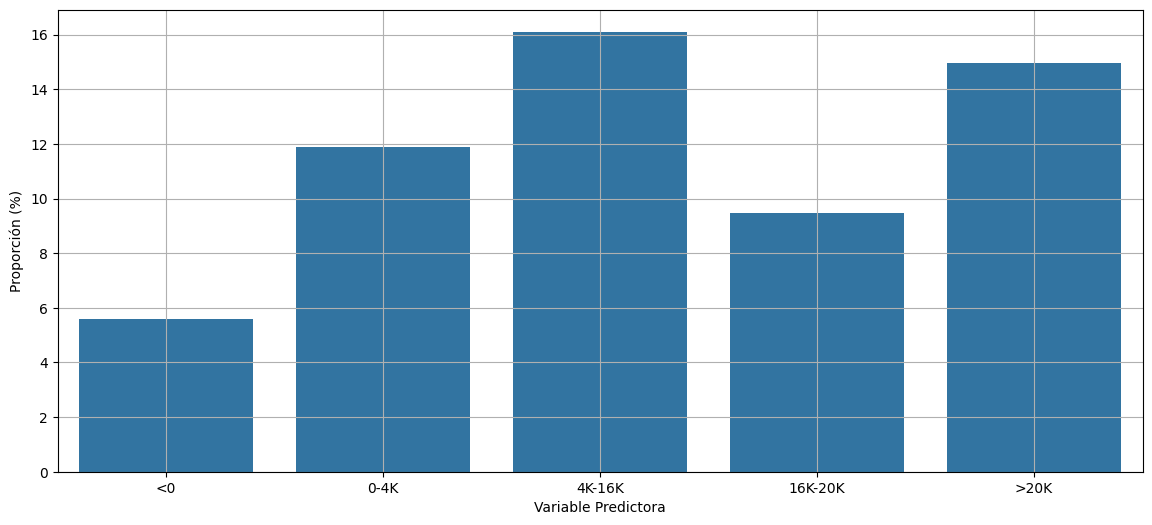

In [101]:
# Generemos el dataset únicamente con estos rangos y observemos el comportamiento

# Nueva columna en el dataset: "grupos_balance"
data.loc[:,'grupos_balance'] = "<0"
data.loc[(data['balance']>=0) & (data['balance']<4000),'grupos_balance'] = "0-4K"
data.loc[(data['balance']>=4000) & (data['balance']<16000),'grupos_balance'] = "4K-16K"
data.loc[(data['balance']>=16000) & (data['balance']<20000),'grupos_balance'] = "16K-20K"
data.loc[data['balance']>=20000,'grupos_balance'] = ">20K"

# Y grafiquemos la tasa de conversión para esta nueva columna
orden = ['<0','0-4K','4K-16K','16K-20K','>20K']
graficar_tasas_conversion('grupos_balance','y_bin',type='bar', order=orden)

In [102]:
# Y eliminemos la columna "balance" para quedarnos con la variable de los grupos
data.drop(columns=['balance'], inplace=True)

Ahora realizaremos un análisis similar pero para las variables categóricas de tal manera que podremos revisar si las categorías tienen un comportamiento similar y no generar diferencias relevantes y en verdad si tienen variabiliad importante que puede ayudar a clasificar datos:

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\1912772489.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo = data.groupby(x)[y].mean().mul(100).rename('tasa_conv').reset_index()


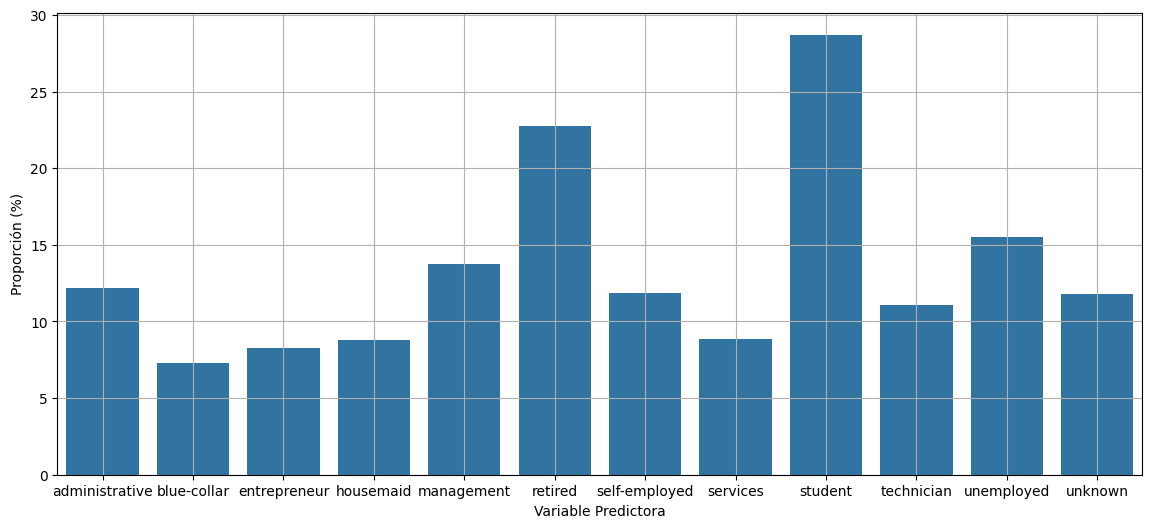

In [103]:
graficar_tasas_conversion('job', 'y_bin', type='bar')

**Observaciones:**

- Las tasas de conversión oscilan entre 8% y 28% aproximadamente
- Los trabajos "retired" y "student" tienen las tasas de conversión más altas (23% y 28%)
- "Job" podría ser una variable predictora pues es fácil identificar que si hay un comportamiento que muestre diferencias según el perfil de la persona

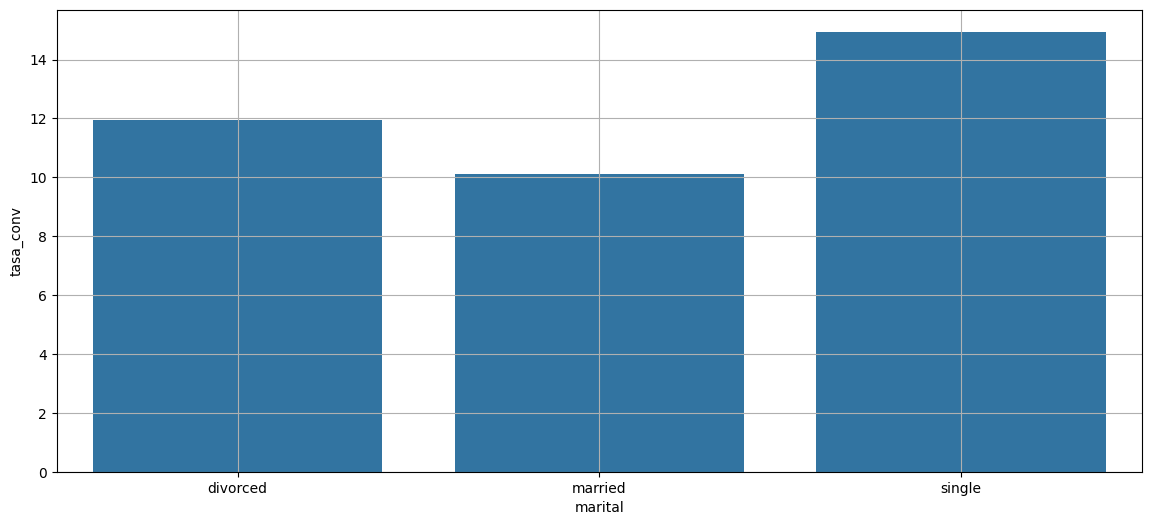

In [22]:
# Marital
graficar_tasas_conversion('marital','y_bin',type='bar')

**Observaciones:**

- Las tasas de conversión son muy similares para los diferentes niveles en la variable "marital"
- "Marital" parece no ser una variable predictora. Sin embargo, si hay diferencias por categoria. 

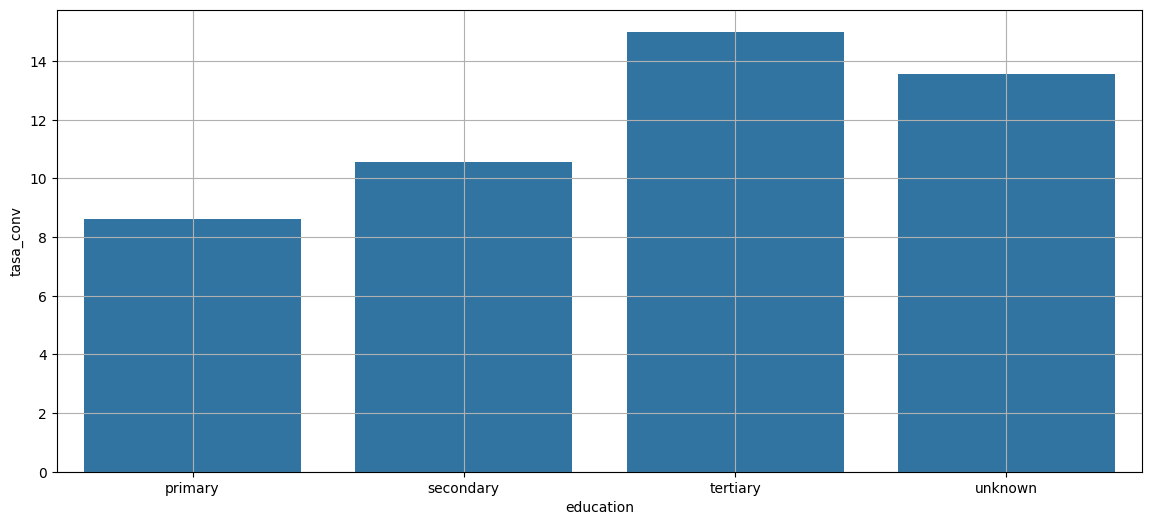

In [23]:
# education
graficar_tasas_conversion('education','y_bin',type='bar')

**Observaciones:**

- Hay un ligero incremento en la tasa de conversión a medida que aumenta el nivel educativo.
- "Education" podría ser una variable predictora

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\3122961085.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo = data.groupby(x)[y].mean().mul(100).rename('tasa_conv').reset_index()


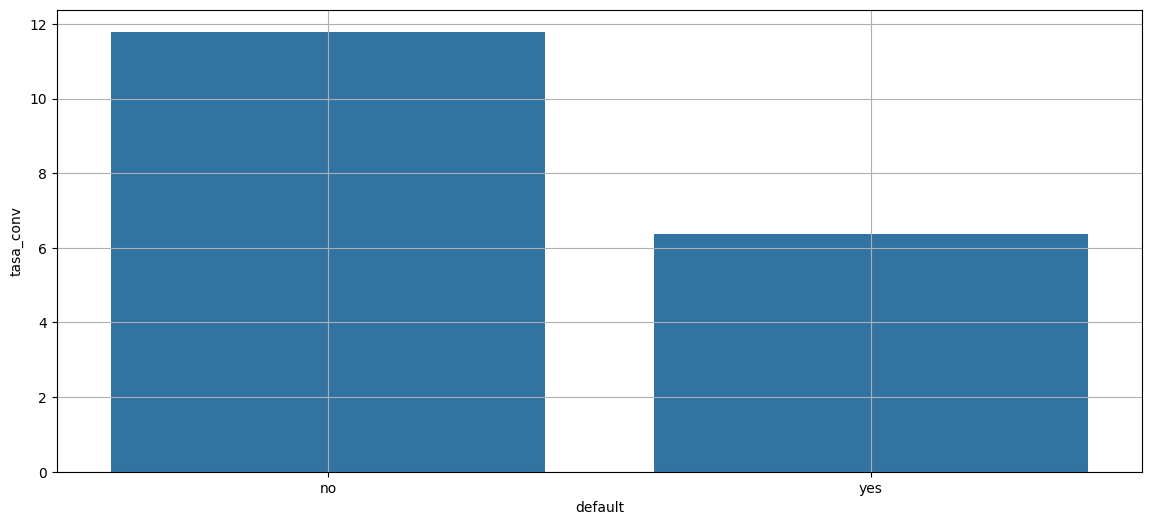

In [62]:
# default, notese que esto si es bastante significativo. 
graficar_tasas_conversion('default','y_bin',type='bar')

**Observaciones**:

- Las tasas de conversión para quienes no tienen "default" son de casi el doble para quienes sí lo tienen (12% vs. 6% aproximadamente).
- "Default" podría ser una variable predictora

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\1912772489.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grupo = data.groupby(x)[y].mean().mul(100).rename('tasa_conv').reset_index()


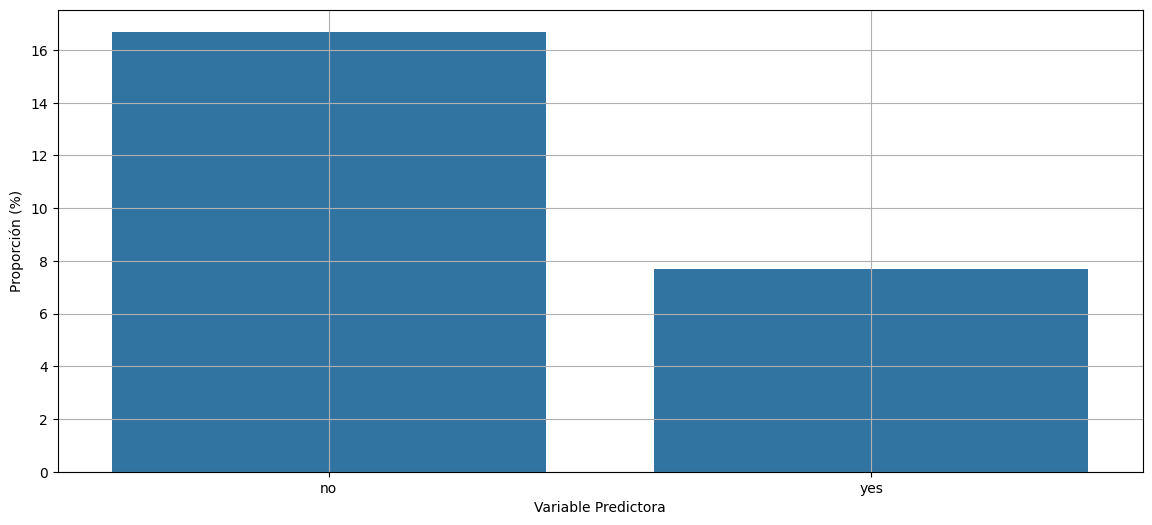

In [104]:
# housing
graficar_tasas_conversion('housing','y_bin',type='bar')

**Observaciones:**

- Quienes no tienen crédito hipotecario ("housing"=no) definitivamente tienen mayores tasas de conversión.
- "Housing" es una variable predictora.

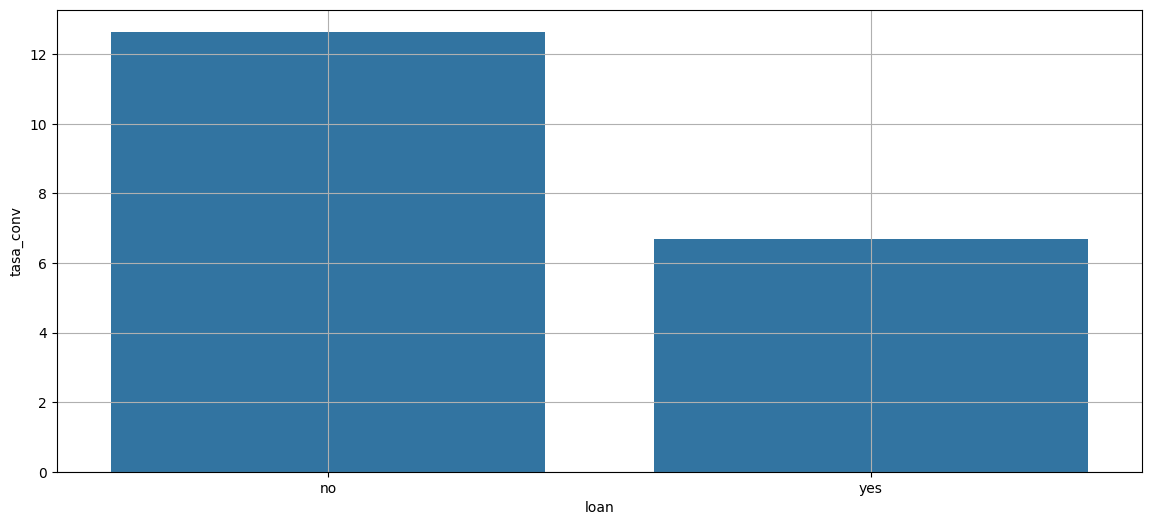

In [28]:
# loan
graficar_tasas_conversion('loan','y_bin',type='bar')

**Observaciones:**

- Con "loan" ocurre algo similar a "housing": quienes NO tienen créditos de consumo presentan definitivamente mayores tasas de conversión
- "Loan" es una variable predictora

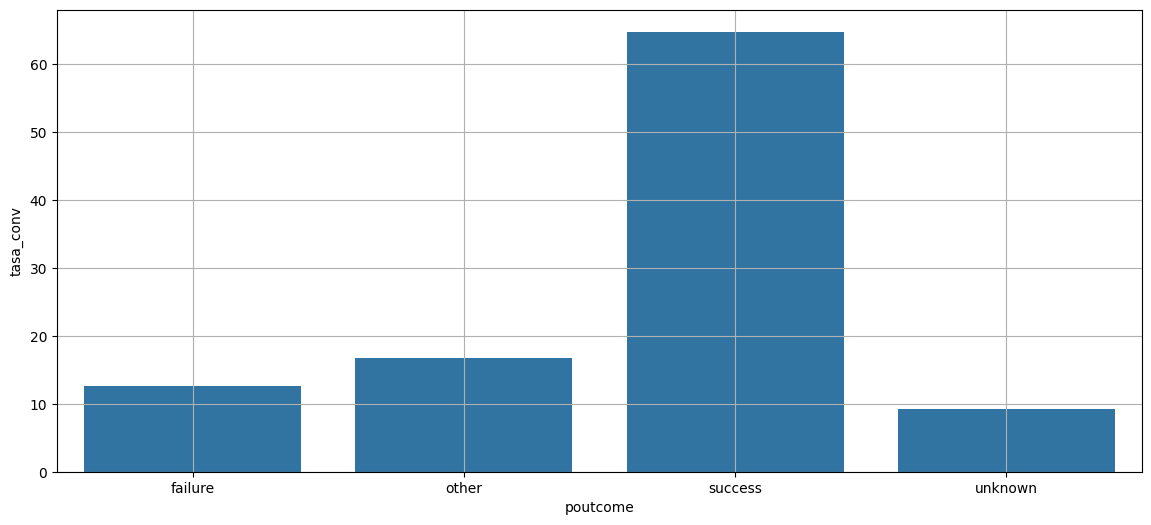

In [26]:
# poutcome
graficar_tasas_conversion('poutcome','y_bin',type='bar')

**Observaciones:**

- Si el cliente adquirió un producto en la campaña anterior (poutcome = success) es más probable que adquiera este nuevo producto con el banco
- poutcome definitivamente es una variable predictora

### Resumen

Las variables predictoras con mayor impacto en la tasa de conversión parecen ser, en orden de importancia

1. poutcome: casi 70% de conversión para el nivel "success"
2. job: con tasas de 22% y 28% para 'retired' y 'student'
2. grupos_balance y grupos_edad, con tasas de conversión cercanas al 16% para varios intervalos
3. default, housing y loan con tasas de conversión entre 12% y 16% para los niveles "no"
4. marital y education, con niveles de conversión comparables con default, housing y loan.

Por tanto, son variables que al ser comparadas con las personas que son el objetivo de nosotros, pertenecer a una de sus categorías puede ser determinante. 

Todas aquellas variables que muestran un comportamiento diferente entre sus categorías pueden ser muy útiles.  

## 4.3 Análisis bivariado

Y podemos ir un paso más allá en este análisis exploratorio y analizar posibles interacciones entre pares de variables predictoras y su impacto en la variable a predecir.

Esto se conoce como análisis bivariado.

Como existen muchas posibles combinaciones analizaremos únicamente los pares con mayor potencial según el orden de importancia definido en el resumen del análisis univariado.

La forma más sencilla de hacer este análisis es a través de gráficas (aunque también se podrían usar herramientas estadísticas más sofisticadas).

▶ ADVERTENCIA ◀

De forma similar a como ocurre con el análisis univariado, este análisis nos mostrará sólo una faceta de las posibles relaciones entre pares de variables predictoras y la variable a predecir, y no es suficiente para extraer conclusiones definitivas (aunque nos dará una pista más detallada en comparación con el análisis univariado).

In [105]:
# Tasa de conversión para dos columnas
def graficar_tc_bivariada(col_list, orden=None):

  #Agrupar los datos de col_list la categórica y y_bin la numérica de la cual
  #se va a calcular el promedio.
  
  #to_frame: convierte del resultado en un dataframe
  #rest_index(): elimina el índice anterior sin convertirlo en columna
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()

  # Gráfica
  plt.figure(figsize=(13,7))

  #Eje X es la variable respuesta, la variable Y categórica y 
  # hue: indica que los puntos se llenan con la variable numérica 
  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)
  ax.yaxis.grid(True)
  ax.xaxis.grid(True)
  plt.title(f'Tasa de conversión para {col_list[0]} y {col_list[1]}')
  plt.xlabel('Tasa de conversión (%)')
  plt.xlim((0,1));

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\2224150998.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\2224150998.py:16: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)


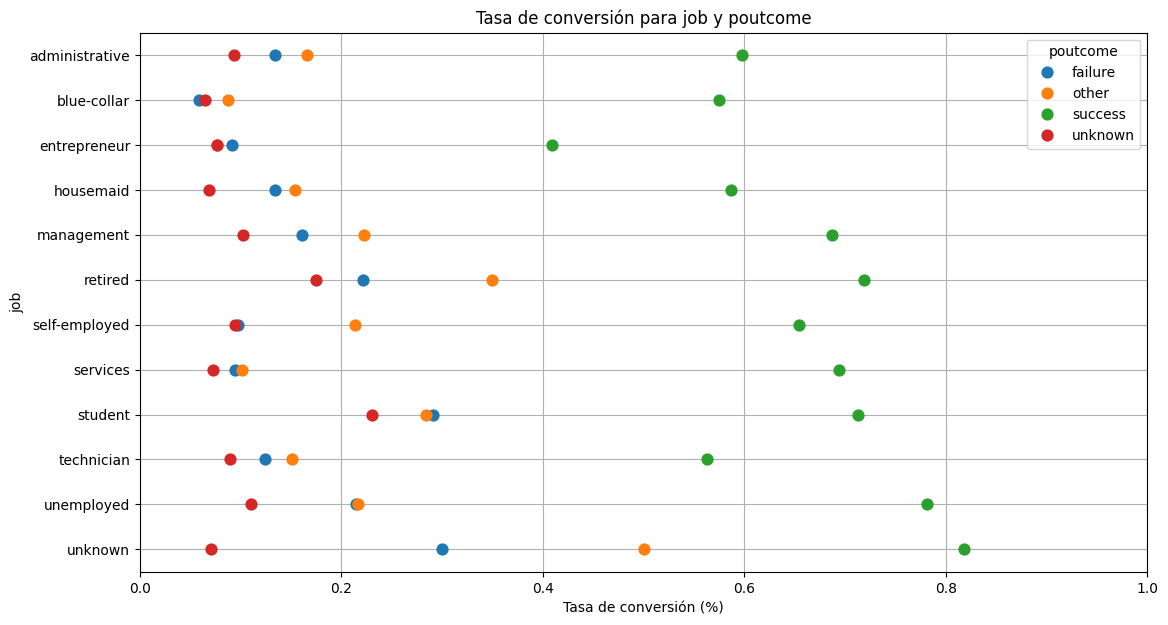

In [106]:
# 1. Par poutcome-job
graficar_tc_bivariada(['job','poutcome'])

# Tasas de conversión superiores al 60% con poutcome==success y
# job = unemployed (78%), student/retired (72%), services (70%),
# management (68%), self-employed (65%)

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)


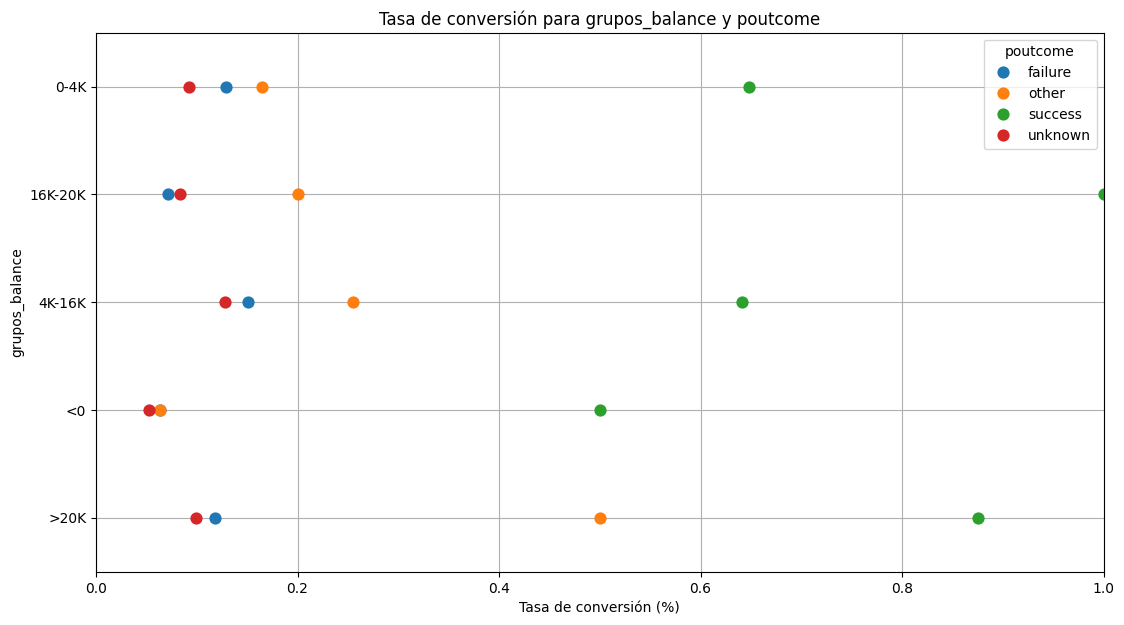

In [65]:
#2. Par poutcome-grupos_balance
graficar_tc_bivariada(['grupos_balance','poutcome'])

# Tasas de conversión superiores al 60% para poutcome=success y
# - Ingresos entre 16K y 20K: 100%!!! Es interesante, pues al analizar sólo
#   la variable ingresos en este rango se obtienen las menores tasas de conversión
# - Ingresos superiores a 20K: 88%
# - Ingresos entre 0-16K: 65%

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)


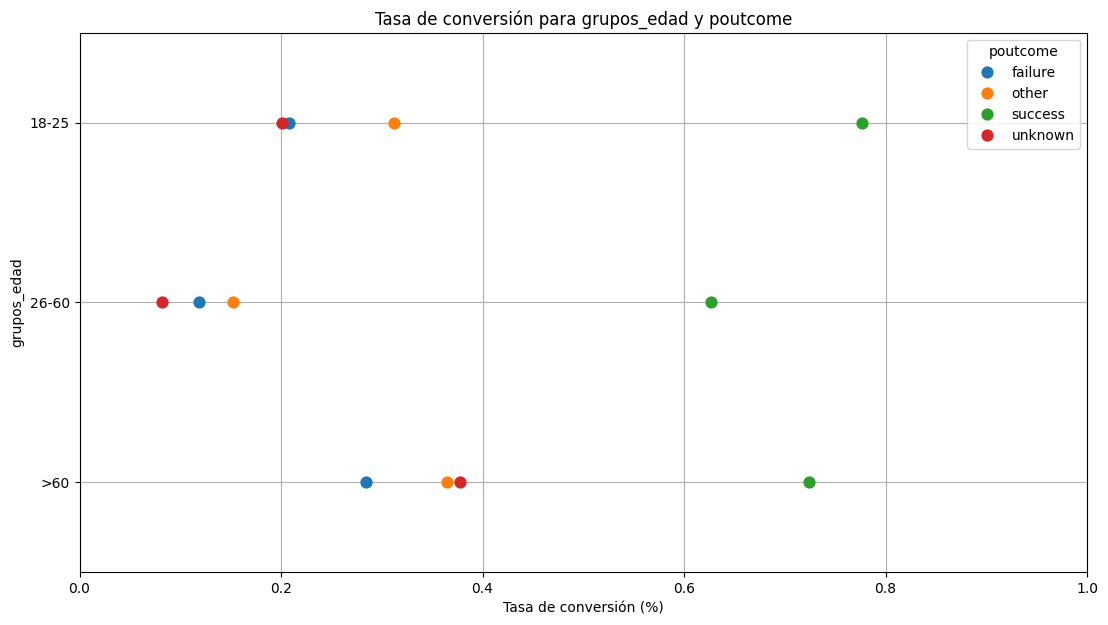

In [66]:
#3. Par poutcome-grupos_edad
graficar_tc_bivariada(['grupos_edad','poutcome'])

# Tasas de conversión superiores al 60% para poutcome=success y
# - Edades 18-25: 78%
# - Edades >60: 72%
# - Edades 26-60: 62%

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)


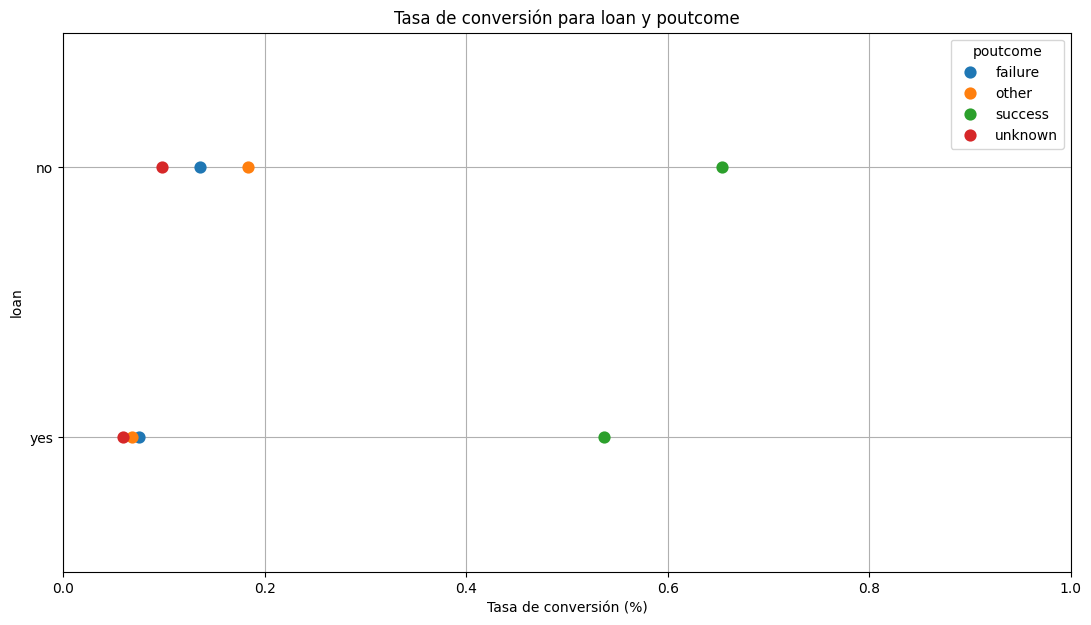

In [67]:
#4. Pares poutcome + default/housing/loan
graficar_tc_bivariada(['loan','poutcome'])

# Se alcanzan tasas de conversión entre 60 y 65% para
# las combinaciones poutcome=success y default/housing/loan=no

C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tc = data.groupby(col_list)['y_bin'].mean().to_frame().reset_index()
C:\Users\mtang\AppData\Local\Temp\ipykernel_11044\4140628471.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x=tc['y_bin'], y=tc[col_list[0]], hue=tc[col_list[1]], join=False, order=orden)


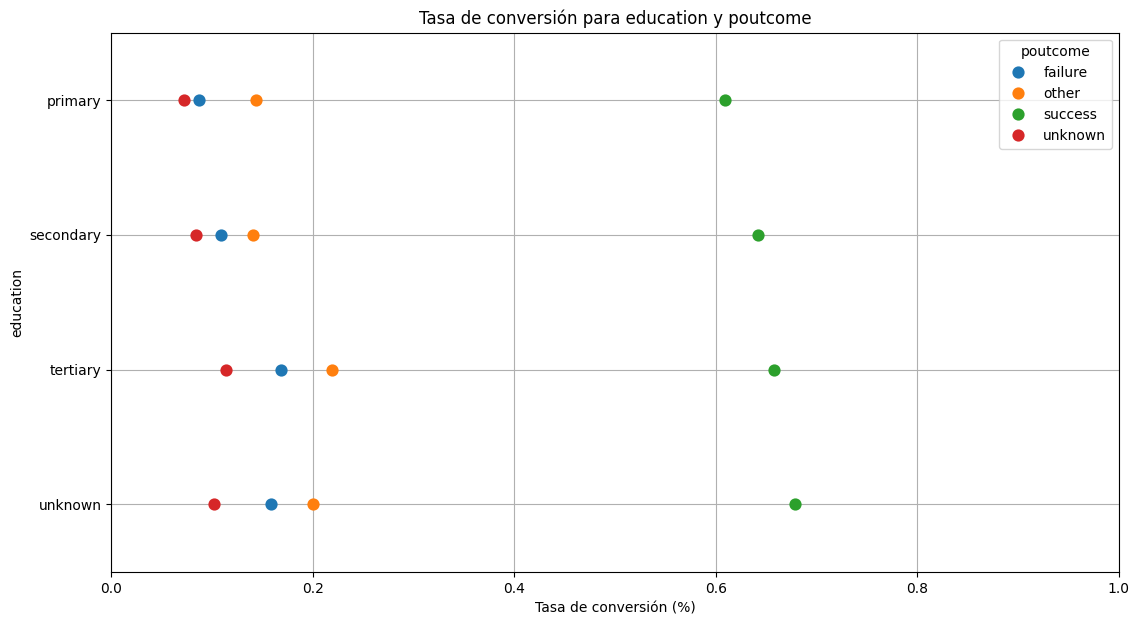

In [68]:
#4. Pares poutcome + marital/education
graficar_tc_bivariada(['education','poutcome'])

# - Se alcanzan tasas de conversión entre 60 y 65% independientemente de "marital"
# - Y lo mismo para "education"

# Estas variables no resultan tan relevantes

# Conclusiones

- La variable "poutcome" seguida de las variables "job", "grupos_balance" y "grupos_edad" son las que tienen mayor impacto en la tasa de conversión.
- Con este análisis el perfil ideal de cliente sería:
    - Debe haber sido contactado previamente por el banco y debe haber adquirido previamente dicho producto (*poutcome == success*)
    - Perfil laboral (top-3): desempleado, estudiante, jubilado
    - Saldo en su cuenta bancaria: entre 16K y 20K (preferiblemente)
    - Edad: entre 18 y 25 años (preferiblemente)
    - Que NO cuente con crédito de consumo, crédito hipotecario o que no haya entrado en "default"


Es posible que la combinación de más de dos variables (análisis multivariado) arroje más luces sobre estos perfiles. Pero en este caso la interpretación de los resultados se dificulta a medida que analizamos de manera simultánea más y más variables.

En este punto el paso a seguir sería usar algún modelo de Machine Learning que permita encontrar esos patrones que no resultan fáciles de ver con este análisis exploratorio.

**En resúmen**
Luego de hacer la limpieza variable por variable para corregir cualquier tipo de error de corrección dentro de los datos, ya sean numéricos o categóricos, se realiza con análisis estadístico donde acá los errores a tratar son varolres atípicos y valores nulos los cuales pueden darse por distintas razones y hay varias formas de tratar con ellos según el caso. 

Se realiza un análisis estadístico univariado para ver el comportamiento de la varaible: si es cuantitativa se mira su distribución, histograma, sesgos, y asimetrías pero si es cualitativa pues solo puede verse su conteo. 

Además, se mira la relación entre cada una de las variables y la variable respuesta y se toma la decisión si tal vez la discretización puede ser lo más adecuado para el problema. 

Posteriormente, se realiza un análisis bivariado análizando el comportamiento de dos varibles con la variable respuesta viendo si hay alguna relación importante que rescatar para saber el tipo de individuos satisfacen mayormente nuestro objetivo. 